In [66]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import json
import torch

from ca_sae.sae.ca_sae import ClassAlignedSAE

In [49]:
sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_v2/").cpu()
sae.eval()

k_budget = torch.softmax(sae.budget_vector, dim=0).detach()

In [57]:
entropy = torch.load("../experiment_results/entropy/ca_saev2.pt")['entropy']

In [69]:
torch.corrcoef(torch.stack([entropy, k_budget]))
spearmanr(entropy, k_budget)

SignificanceResult(statistic=np.float64(-0.17085158163233582), pvalue=np.float64(3.3366765446131157e-28))

In [59]:
en_s, k_s = zip(*sorted(list(zip(entropy, k_budget)), key=lambda x: x[0]))

In [60]:
entropy.min(), entropy.max()


(tensor(0.1955), tensor(6.8672))

In [63]:
k_budget.min(), k_budget.max()

(tensor(9.3056e-06), tensor(0.0310))

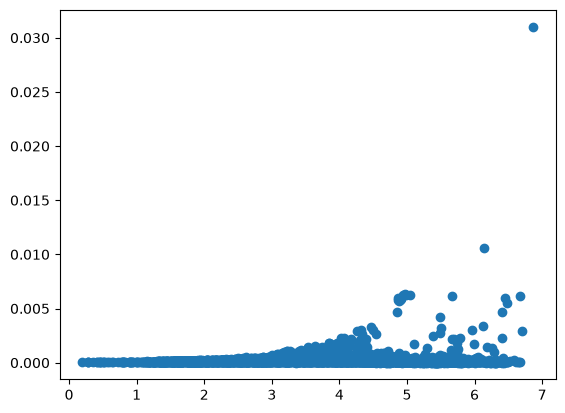

In [64]:
plt.scatter(entropy, k_budget)